## Cosmology: Background and Perturbations for binned DE

* change expansion: $$ \frac{H^2(z)}{H_0^2} = \Omega_{\rm m} (1+z)^3 + (1-\Omega_{\rm m}) f_{\rm DE}(z)$$ with $$f_{\rm DE}(z) = \left( \frac{1+z}{1+z_j-\Delta z_j/2} \right)^{3(1+w_j)} \Pi^{j-1}_{i=1} \left( \frac{1+z_i+\Delta z_i/2}{1+z_i-\Delta z_i/2}\right)^{3(1+w_i)}$$ vs $$f_{\rm DE}(z) = f_i$$ with $z_i-\frac{\Delta z_i}{2}<z<z_i+\frac{\Delta z_i}{2}$
* change distances: $r_{\rm com}(z)=\int_0^{z} \frac{c \mathrm{d}z'}{H(z')}$
* change linear growth: JaxMGrowth

In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner

import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

/Users/s2265800/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


In [2]:
import time

In [3]:
from cloelib.cosmology.binned_wz_cosmology import DEBinnedEoSBackground, DEBinnedEoSLinearPerturbations, DEBinnedEoSNonlinearPerturbations
from cloelib.cosmology.binned_fdez_cosmology import DEBinnedDensityBackground, DEBinnedDensityLinearPerturbations, DEBinnedDensityNonlinearPerturbations

Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


# Cosmology: Background 

## 4 bins + high-redshift bin 

In [4]:
w0 = -0.75
wa = -0.86
background_lcdm = CAMBBackground(H0=67.0, 
                            Omega_cdm0=0.27, 
                            Omega_b0=0.049, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2.1e-9,
                            mnu = 0.077,
                            gamma_MG = 0.545,
                            N_mnu=1)
background_cpl = CAMBBackground(H0=67.0, 
                            Omega_cdm0=0.27, 
                            Omega_b0=0.049, 
                            w0=w0, 
                            wa=wa, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2.1e-9,
                            mnu = 0.077,
                            gamma_MG = 0.545,
                            N_mnu=1)

In [34]:
from scipy.integrate import quad
def w_of_z_cpl(z, w0, wa):
    z = np.asarray(z)
    return w0 + wa * z / (1.0 + z)
def fde_cpl(z):
    de_integrand = lambda zp: (1.0 + w_of_z_cpl(zp, w0, wa)) / (1.0 + zp)
    return np.exp(3.0 * quad(de_integrand, 0.0, float(z))[0])


zs = np.linspace(1e-4, 3, 100)
zfinal = 1000.
zmax = 3.
zmin_desi = 0.1
zmin = 0.
number_of_bins = 4

zbin_edges = np.array([zmin+(zmax-zmin)/number_of_bins*i for i in range(number_of_bins+1)]+[zfinal])
zbin_centers = 0.5*(zbin_edges[1:] + zbin_edges[:-1])
zbin_widths = np.diff(np.array(zbin_edges))
w_i_amp_cpl_centers = np.array([w0+wa*(zbin_centers[i]/(1.+zbin_centers[i])) for i in range(len(zbin_centers))])
fde_i_amp_cpl_centers = np.array([fde_cpl(zbin_centers[i]) for i in range(len(zbin_centers))])
n_bin = len(zbin_centers)
print('for step-function (without smoothing:')
print('w_i_centers: ', w_i_amp_cpl_centers)
print('fde_i_centers: ', fde_i_amp_cpl_centers)
print('z-bin edges: ', zbin_edges)
print('z-bin widths: ', zbin_widths)
print('z-bin centers: ', zbin_centers)
print('Nbin: ', n_bin, len(w_i_amp_cpl_centers))



for step-function (without smoothing:
w_i_centers:  [-0.98454545 -1.20529412 -1.31086957 -1.37275862 -1.60828856]
fde_i_centers:  [1.12847373e+00 9.86570940e-01 7.78825940e-01 6.13547566e-01
 1.49682474e-04]
z-bin edges:  [0.00e+00 7.50e-01 1.50e+00 2.25e+00 3.00e+00 1.00e+03]
z-bin widths:  [7.50e-01 7.50e-01 7.50e-01 7.50e-01 9.97e+02]
z-bin centers:  [3.750e-01 1.125e+00 1.875e+00 2.625e+00 5.015e+02]
Nbin:  5 5


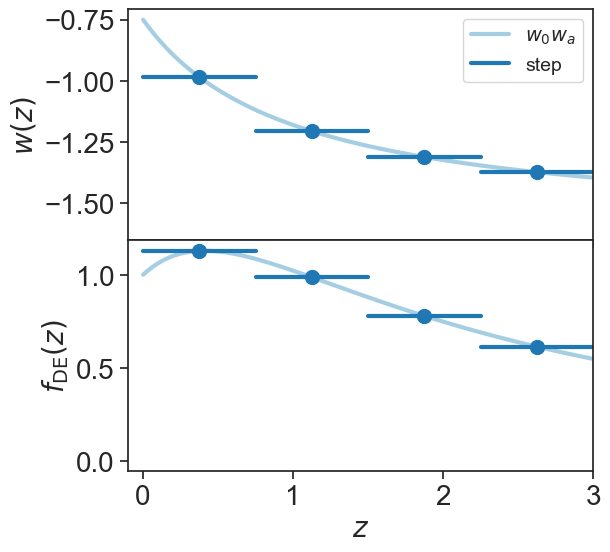

In [35]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(6, 6), sharex=True, 
                                gridspec_kw={'height_ratios': [1, 1], 'hspace': 0})
ax[0].errorbar(zbin_centers, w_i_amp_cpl_centers,   marker='o',  markersize=10, linestyle='',color='C1')
ax[1].errorbar(zbin_centers, fde_i_amp_cpl_centers,   marker='o',  markersize=10, linestyle='',color='C1')
ax[0].plot(zs, w0+wa*(zs/(1.+zs)), label='$w_0w_a$', color='C0')
ax[1].plot(zs, [fde_cpl(zs_i) for zs_i in zs], label='$w_0w_a$', color='C0')
for i in range(4):
    z_arr = np.linspace(zbin_edges[i], zbin_edges[i+1], 10)
    ax[0].plot(z_arr, w_i_amp_cpl_centers[i]*np.ones(10), color='C1', label='step' if i==0 else '')
    ax[1].plot(z_arr, fde_i_amp_cpl_centers[i]*np.ones(10), color='C1')
    
# for i in range(len(zbin_edges)):
#     ax[0].axvline(zbin_edges[i], ls='--', color='grey')
#     ax[1].axvline(zbin_edges[i], ls='--', color='grey')
ax[1].set_xlabel('$z$')
ax[0].set_ylabel('$w(z)$')
ax[1].set_ylabel(r'$f_{\rm DE}(z)$')
ax[0].set_xlim(-0.1, 3)
ax[0].legend()
plt.show()

In [36]:
# The arguments of the Background functions follow the cosmology.API
background_de_wz = DEBinnedEoSBackground(H0=67.0, 
                            Omega_cdm0=0.27, 
                            Omega_b0=0.049, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2.1e-9,
                            mnu = 0.077,
                            zbin_edges = zbin_edges,
                            w_i = w_i_amp_cpl_centers
                            )
background_de_fde = DEBinnedDensityBackground(H0=67.0, 
                            Omega_cdm0=0.27, 
                            Omega_b0=0.049, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2.1e-9,
                            mnu = 0.077,
                            zbin_edges = zbin_edges,
                            fde_i = fde_i_amp_cpl_centers
                            )


In [37]:
zs0 = np.array([0.])
zs0 = 0.
print(background_cpl.Omega_m(zs0))
print(background_de_wz.Omega_m(zs0))
print(background_de_fde.Omega_m(zs0))


0.32084357042900397
0.3208416406233968
0.2950935466305146


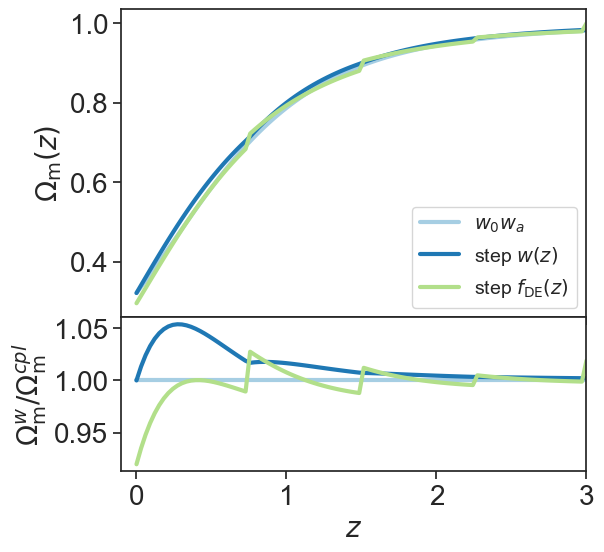

In [38]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True, 
                                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})
ax1.plot(zs, background_cpl.Omega_m(zs), label='$w_0w_a$', color='C0')
ax1.plot(zs, background_de_wz.Omega_m(zs), label='step $w(z)$', color='C1')
ax1.plot(zs, background_de_fde.Omega_m(zs), label=r'step $f_{\rm DE}(z)$', color='C2')


ax2.plot(zs, background_cpl.Omega_m(zs)/background_cpl.Omega_m(zs), label='$w_0w_a$', color='C0')
ax2.plot(zs, background_de_wz.Omega_m(zs)/background_cpl.Omega_m(zs), label='step $w(z)$', color='C1')
ax2.plot(zs, background_de_fde.Omega_m(zs)/background_cpl.Omega_m(zs), label=r'step $f_{\rm DE}(z)$', color='C2')


# for i in range(len(zbin_edges)):
#     ax1.axvline(zbin_edges[i], ls='--', color='grey')

ax2.set_xlabel('$z$')
ax1.set_ylabel('$\\Omega_{\\rm m}(z)$')
ax2.set_ylabel('$\\Omega^{w}_{\\rm m}/\\Omega^{cpl}_{\\rm m}$')
ax2.set_xlim(-0.1, 3)
ax1.legend()
plt.show()

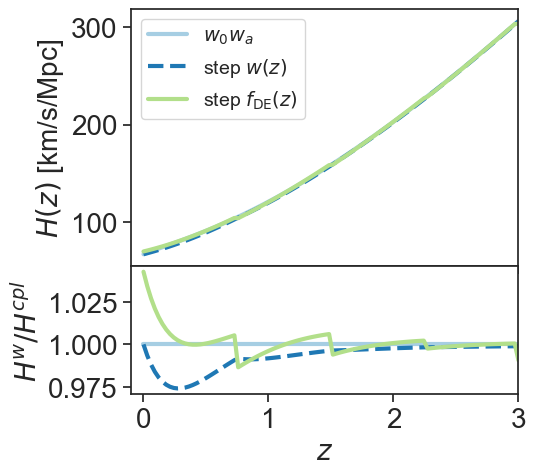

In [39]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, 
                                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})
ax1.plot(zs, background_cpl.hubble_parameter(zs), label='$w_0w_a$', color='C0')
ax1.plot(zs, background_de_wz.hubble_parameter(zs), label='step $w(z)$', color='C1', linestyle='--')
ax1.plot(zs, background_de_fde.hubble_parameter(zs), label=r'step $f_{\rm DE}(z)$', color='C2')


ax2.plot(zs, background_cpl.hubble_parameter(zs)/background_cpl.hubble_parameter(zs), label='$w_0w_a$', color='C0')
ax2.plot(zs, background_de_wz.hubble_parameter(zs)/background_cpl.hubble_parameter(zs), label='step $w(z)$', color='C1', linestyle='--')
ax2.plot(zs, background_de_fde.hubble_parameter(zs)/background_cpl.hubble_parameter(zs), label=r'step $f_{\rm DE}(z)$', color='C2')


# for i in range(len(zbin_edges)):
#     ax1.axvline(zbin_edges[i], ls='--', color='grey')

ax2.set_xlabel('$z$')
ax1.set_ylabel('$H(z)$ [km/s/Mpc]')
ax2.set_ylabel('$H^{w}/H^{cpl}$')
ax2.set_xlim(-0.1, 3)
ax1.legend()
plt.show()

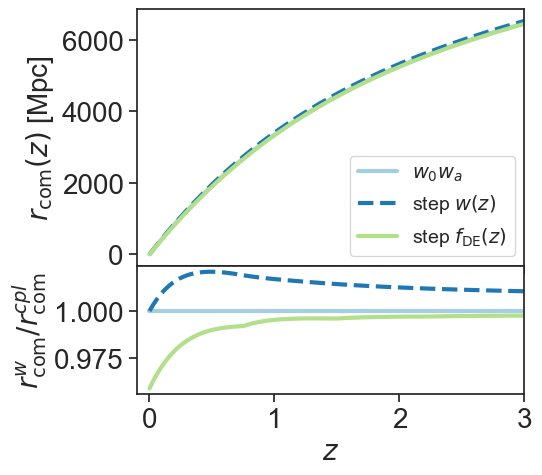

In [40]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, 
                                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})
ax1.plot(zs, background_cpl.comoving_distance(zs), label='$w_0w_a$', color='C0')
ax1.plot(zs, background_de_wz.comoving_distance(zs), label='step $w(z)$', color='C1', linestyle='--')
ax1.plot(zs, background_de_fde.comoving_distance(zs), label=r'step $f_{\rm DE}(z)$', color='C2')


ax2.plot(zs, background_cpl.comoving_distance(zs)/background_cpl.comoving_distance(zs), label='$w_0w_a$', color='C0')
ax2.plot(zs, background_de_wz.comoving_distance(zs)/background_cpl.comoving_distance(zs), label='step $w(z)$', color='C1', linestyle='--')
ax2.plot(zs, background_de_fde.comoving_distance(zs)/background_cpl.comoving_distance(zs), label=r'step $f_{\rm DE}(z)$', color='C2')


# for i in range(len(zbin_edges)):
#     ax1.axvline(zbin_edges[i], ls='--', color='grey')

ax2.set_xlabel('$z$')
ax1.set_ylabel('$r_{\\rm com}(z)$ [Mpc]')
ax2.set_ylabel('$r_{\\rm com}^{w}/r_{\\rm com}^{cpl}$')
ax2.set_xlim(-0.1, 3)
ax1.legend()
plt.show()

# Perturbations: linear and nonlinear

In [41]:
linear_perturbations_lcdm = HMemuLinearPerturbations(background_lcdm, zs)
linear_perturbations_cpl = HMemuLinearPerturbations(background_cpl, zs)

log10_t_agn = 7.75

nonlinear_perturbations_lcdm = HMemuNonLinearPerturbations(background_lcdm, linear_perturbations_lcdm, zs, log10TAGN=log10_t_agn)
nonlinear_perturbations_cpl = HMemuNonLinearPerturbations(background_cpl, linear_perturbations_cpl, zs, log10TAGN=log10_t_agn)

In [42]:
linear_perturbations_de_wz = DEBinnedEoSLinearPerturbations(background_de_wz, linear_perturbations_lcdm)
linear_perturbations_de_fde = DEBinnedDensityLinearPerturbations(background_de_fde, linear_perturbations_lcdm)
nonlinear_perturbations_de_wz = DEBinnedEoSNonlinearPerturbations(background_de_wz, linear_perturbations_de_wz, zs, log10TAGN=log10_t_agn)
nonlinear_perturbations_de_fde = DEBinnedDensityNonlinearPerturbations(background_de_fde, linear_perturbations_de_fde, zs, log10TAGN=log10_t_agn)

In [43]:
ks = np.logspace(np.log10(1e-3), np.log10(5), 100)
ps_lin_lcdm = linear_perturbations_lcdm.matter_power_spectrum(0, ks)
ps_lin_cpl = linear_perturbations_cpl.matter_power_spectrum(0, ks)
ps_lin_de_wz = linear_perturbations_de_wz.matter_power_spectrum(0, ks)
ps_lin_de_fde = linear_perturbations_de_fde.matter_power_spectrum(0, ks)
ps_nonlin_lcdm = nonlinear_perturbations_lcdm.matter_power_spectrum(0, ks)
start = time.time()
ps_nonlin_cpl = nonlinear_perturbations_cpl.matter_power_spectrum(0, ks)
finish = time.time()
print(finish-start)
start = time.time()
ps_nonlin_de_wz = nonlinear_perturbations_de_wz.matter_power_spectrum(0, ks)
ps_nonlin_de_fde = nonlinear_perturbations_de_fde.matter_power_spectrum(0, ks)
finish = time.time()
print(finish-start)
print(ps_nonlin_cpl.shape, ps_nonlin_de_wz.shape, ps_nonlin_de_fde.shape, ps_lin_cpl.shape, ps_lin_de_wz.shape, ps_lin_de_fde.shape)

2.7179718017578125e-05
4.696846008300781e-05
(1, 100) (1, 100) (1, 100) (100,) (1, 100) (1, 100)


Text(0.5, 1.0, 'Ratio')

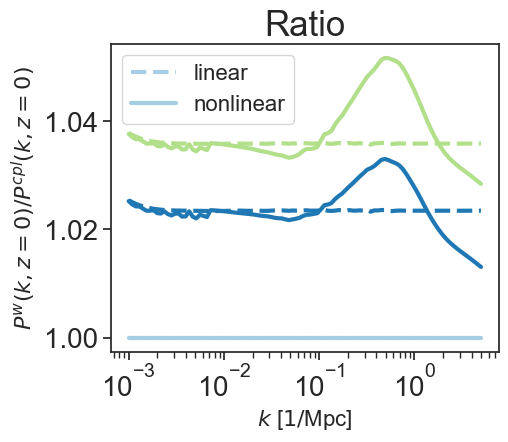

In [44]:
# Create the figure
plt.figure(figsize=(5, 4))

plt.semilogx(ks, ps_lin_cpl/ps_lin_cpl, label='linear', color='C0', linestyle='--' )
plt.semilogx(ks, ps_nonlin_cpl[0]/ps_nonlin_cpl[0], label='nonlinear', color='C0' )
plt.semilogx(ks, ps_lin_de_wz[0]/ps_lin_cpl, color='C1' , linestyle='--')
plt.semilogx(ks, ps_nonlin_de_wz[0]/ps_nonlin_cpl[0], color='C1' )
plt.semilogx(ks, ps_lin_de_fde[0]/ps_lin_cpl, color='C2' , linestyle='--')
plt.semilogx(ks, ps_nonlin_de_fde[0]/ps_nonlin_cpl[0], color='C2' )

plt.xlabel('$k$ [$1/$Mpc]', fontsize = 16)
plt.ylabel('$P^{w}(k, z=0)/P^{cpl}(k, z=0)$', fontsize = 16)

plt.legend(fontsize = 16)
plt.title("Ratio")